<a href="https://colab.research.google.com/github/gomesgarcia10/spacex-eda-analise/blob/main/Spacex_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

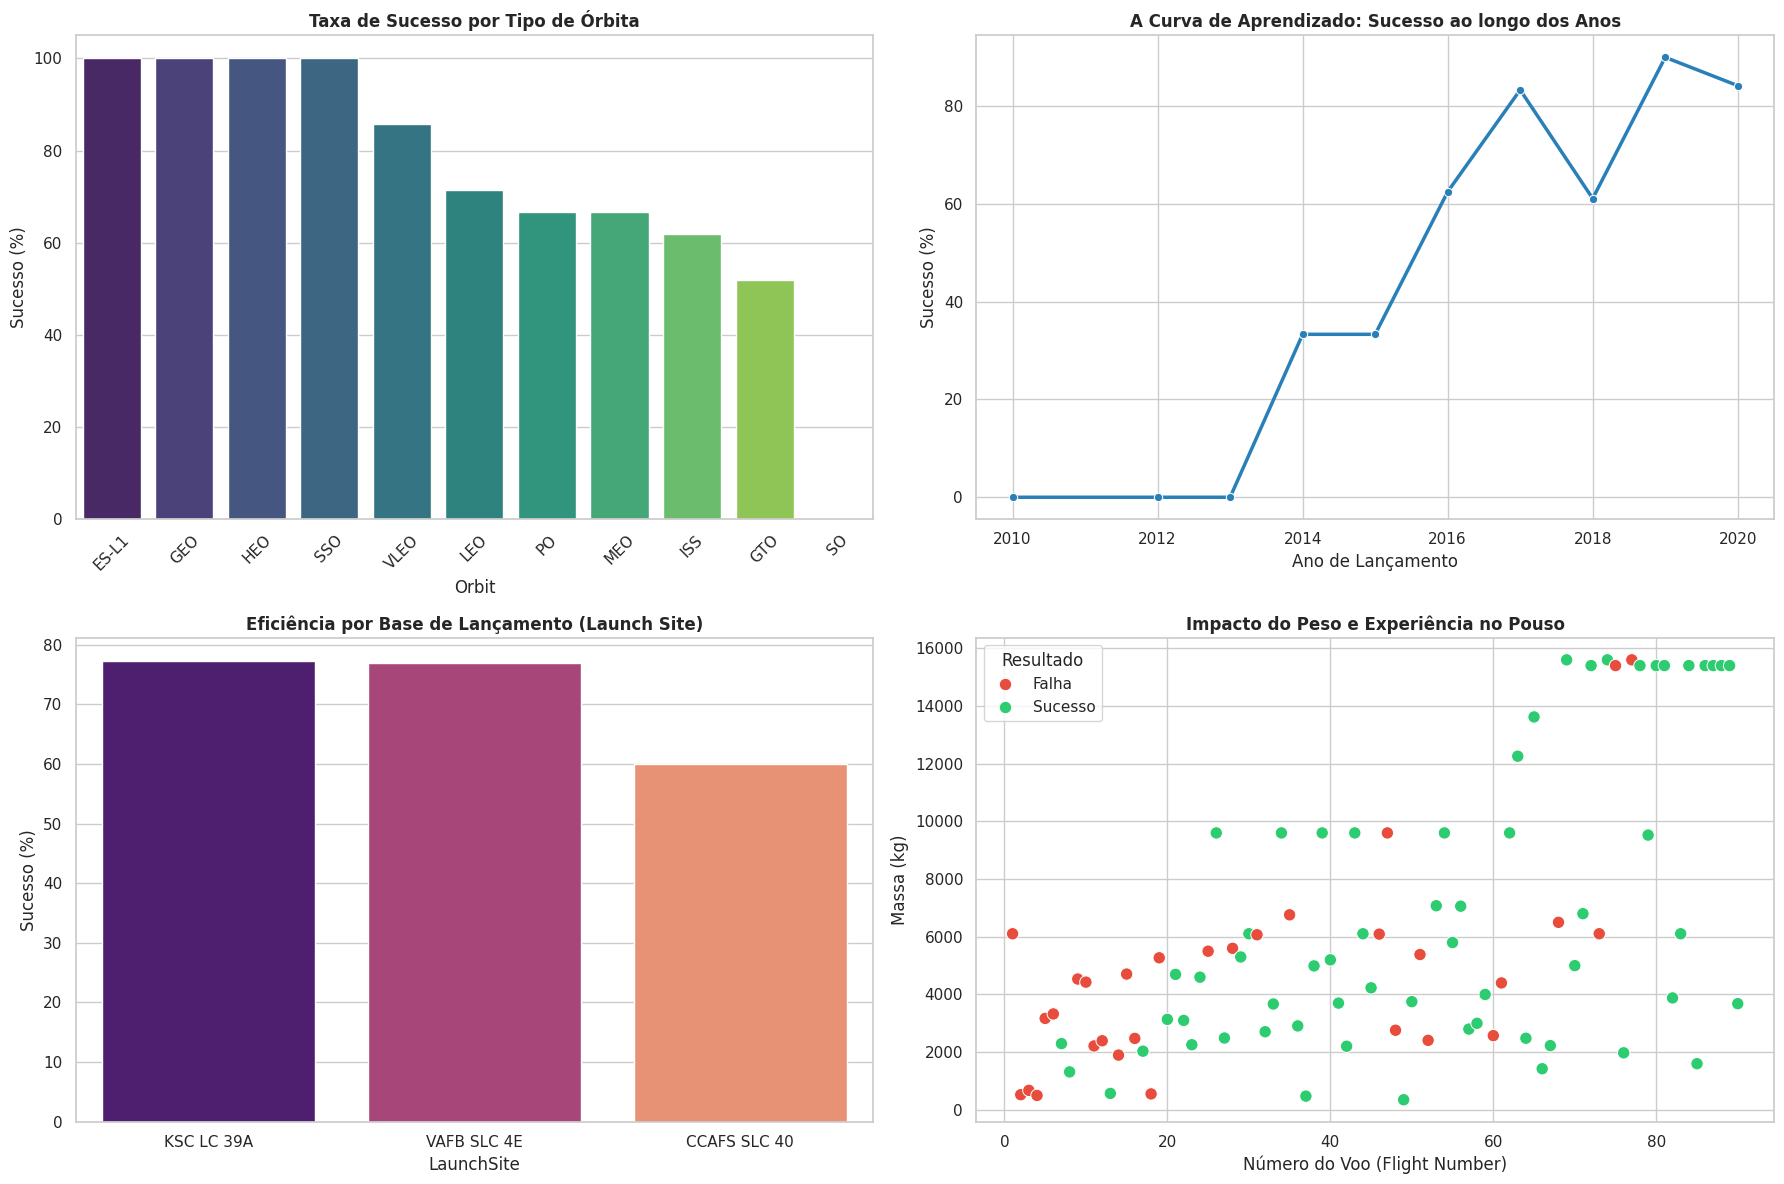

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregando os dados
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
df = pd.read_csv(url)

# 2. Limpeza e Engenharia de Recursos (Feature Engineering)
# Imputação da massa
df['PayloadMass'] = df['PayloadMass'].fillna(df['PayloadMass'].mean())

# Extraindo o Ano da coluna 'Date' para análise temporal
df['Year'] = pd.to_datetime(df['Date']).dt.year

# 3. Configurando o Dashboard (Grade 2x2)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# --- GRÁFICO 1: Sucesso por Órbita (Original) ---
sucesso_orbita = df.groupby('Orbit')['Class'].mean().sort_values(ascending=False) * 100
sns.barplot(x=sucesso_orbita.index, y=sucesso_orbita.values, ax=axes[0, 0], palette="viridis", hue=sucesso_orbita.index, legend=False)
axes[0, 0].set_title('Taxa de Sucesso por Tipo de Órbita', fontweight='bold')
axes[0, 0].set_ylabel('Sucesso (%)')
axes[0, 0].tick_params(axis='x', rotation=45);

# --- GRÁFICO 2: Evolução Temporal (Novo) ---
sucesso_ano = df.groupby('Year')['Class'].mean() * 100
sns.lineplot(x=sucesso_ano.index, y=sucesso_ano.values, ax=axes[0, 1], marker='o', color='#2980b9', linewidth=2.5)
axes[0, 1].set_title('A Curva de Aprendizado: Sucesso ao longo dos Anos', fontweight='bold')
axes[0, 1].set_ylabel('Sucesso (%)')
axes[0, 1].set_xlabel('Ano de Lançamento')

# --- GRÁFICO 3: Sucesso por Base de Lançamento (Novo) ---
sucesso_base = df.groupby('LaunchSite')['Class'].mean().sort_values(ascending=False) * 100
sns.barplot(x=sucesso_base.index, y=sucesso_base.values, ax=axes[1, 0], palette="magma", hue=sucesso_base.index, legend=False)
axes[1, 0].set_title('Eficiência por Base de Lançamento (Launch Site)', fontweight='bold')
axes[1, 0].set_ylabel('Sucesso (%)')

# --- GRÁFICO 4: Carga vs Experiência (Original) ---
sns.scatterplot(data=df, x='FlightNumber', y='PayloadMass', hue='Class',
                palette={0: '#e74c3c', 1: '#2ecc71'}, s=80, ax=axes[1, 1])
axes[1, 1].set_title('Impacto do Peso e Experiência no Pouso', fontweight='bold')
axes[1, 1].set_ylabel('Massa (kg)')
axes[1, 1].set_xlabel('Número do Voo (Flight Number)')
handles, _ = axes[1, 1].get_legend_handles_labels()
axes[1, 1].legend(handles, ['Falha', 'Sucesso'], title='Resultado')

plt.tight_layout()
plt.show()